# Real-data tutorial 3: spatiotemporal Gata3 evidence gate

**Dataset:** Day4/7/10 T/NK perturbation SPAC time course with two
replicates per day.

**Best-supported conclusion:** Day7 `sgGata3` has the strongest V2
empirical signal for NK fraction, but the global FDR is 0.507 and
matching balance fails. The correct conclusion is therefore
**insufficient evidence for a reproducible propagation radius**.

This negative example is scientifically important: a consistent,
visually plausible curve is not enough when multiplicity and
structural balance fail.

## 1. Load frozen V2 audit and result tables

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import perturbradius as pr

DATA_DIR = Path("data")
if not DATA_DIR.exists():
    DATA_DIR = Path("tutorials/data")
if not DATA_DIR.exists():
    raise FileNotFoundError("Run from the repository root or tutorials directory")

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
COLORS = {
    "orange": "#D55E00",
    "blue": "#0072B2",
    "green": "#009E73",
    "purple": "#CC79A7",
    "gray": "#777777",
}
print("PerturbRadius", pr.__version__)

PerturbRadius 0.1.0


In [2]:
anchors = pd.read_csv(DATA_DIR / "spatiotemporal_gata3_anchors.tsv", sep="\t")
coverage = pd.read_csv(DATA_DIR / "spatiotemporal_gata3_coverage.tsv", sep="\t")
curve = pd.read_csv(DATA_DIR / "spatiotemporal_gata3_nk_curve.tsv", sep="\t")
gate = pd.read_csv(DATA_DIR / "spatiotemporal_gata3_nk_gate.tsv", sep="\t")
screen = pd.read_csv(DATA_DIR / "spatiotemporal_robust_screen.tsv", sep="\t")
main_screen = screen.loc[
    screen["inner_buffer"].eq(40)
    & screen["block_size"].eq(400)
].copy()

display(pd.DataFrame({
    "quantity": ["Day7 Gata3 source patches", "Day7 biological replicates",
                 "responses in main screen", "guides in main screen",
                 "coordinate calibration"],
    "value": [
        int(anchors["day"].eq(7).sum()),
        int(anchors.loc[anchors["day"].eq(7), "replicate"].nunique()),
        int(main_screen["response"].nunique()),
        int(main_screen["guide"].nunique()),
        "20-unit grid; not promoted to µm",
    ],
}))

,quantity,value
0,Day7 Gata3 source patches,83
1,Day7 biological replicates,2
2,responses in main screen,14
3,guides in main screen,2
4,coordinate calibration,20-unit grid; not promoted to µm


## 2. Coverage across time and replicate

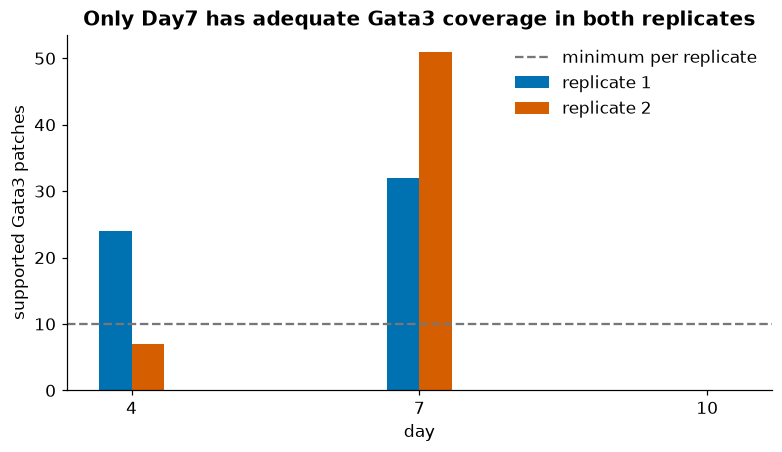

,day,replicate,supported_patches
0,4,1,24
1,4,2,7
2,7,1,32
3,7,2,51
4,10,1,0
5,10,2,0


In [3]:
full_index = pd.MultiIndex.from_product(
    [[4, 7, 10], [1, 2]], names=["day", "replicate"]
)
coverage_full = (
    coverage.set_index(["day", "replicate"])["supported_patches"]
    .reindex(full_index, fill_value=0).reset_index()
)
fig, ax = plt.subplots(figsize=(7.0, 4.0), constrained_layout=True)
width = 0.34
days = np.array([4, 7, 10])
for replicate, offset, color in [
    (1, -width/2, COLORS["blue"]),
    (2, width/2, COLORS["orange"]),
]:
    rows = coverage_full.loc[coverage_full["replicate"].eq(replicate)]
    ax.bar(days + offset, rows["supported_patches"], width,
           color=color, label=f"replicate {replicate}")
ax.axhline(10, color=COLORS["gray"], linestyle="--",
           label="minimum per replicate")
ax.set(xticks=days, xlabel="day", ylabel="supported Gata3 patches")
ax.set_title("Only Day7 has adequate Gata3 coverage in both replicates",
             fontweight="bold")
ax.legend(frameon=False)
plt.show()
display(coverage_full)

## 3. Day7 spatial source-patch distribution

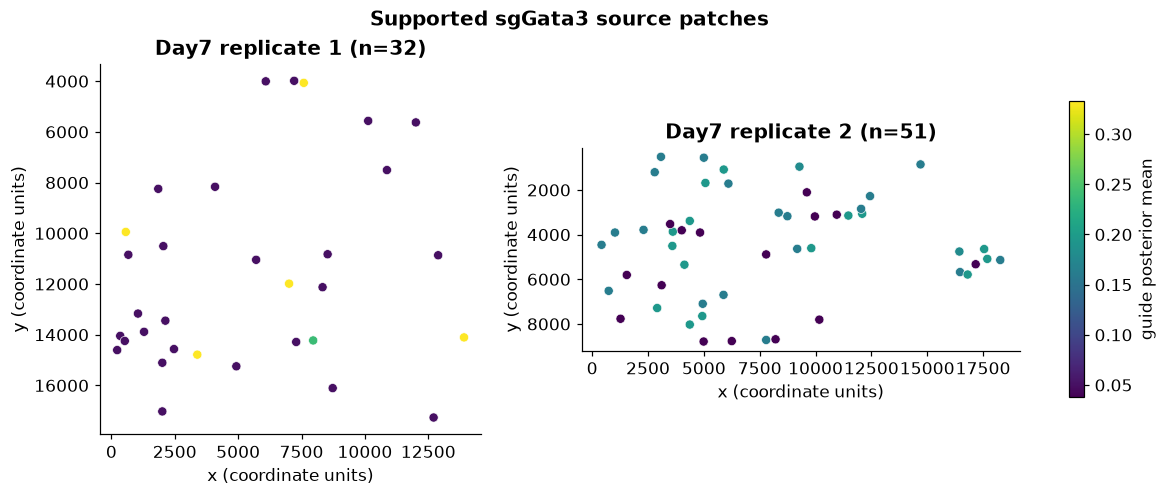

In [4]:
day7 = anchors.loc[anchors["day"].eq(7)].copy()
fig, axes = plt.subplots(1, 2, figsize=(10.8, 4.4), constrained_layout=True)
for ax, replicate in zip(axes, [1, 2]):
    rows = day7.loc[day7["replicate"].eq(replicate)]
    points = ax.scatter(
        rows["center_x"], rows["center_y"],
        c=rows["posterior_mean"], s=36, cmap="viridis",
        vmin=day7["posterior_mean"].min(), vmax=day7["posterior_mean"].max(),
        edgecolor="white", linewidth=0.4,
    )
    ax.set(xlabel="x (coordinate units)", ylabel="y (coordinate units)",
           aspect="equal")
    ax.invert_yaxis()
    ax.set_title(f"Day7 replicate {replicate} (n={len(rows)})",
                 fontweight="bold")
fig.colorbar(points, ax=axes, label="guide posterior mean", shrink=0.8)
fig.suptitle("Supported sgGata3 source patches", fontweight="bold")
plt.show()

## 4. Why Gata3–NK is the top V2 signal

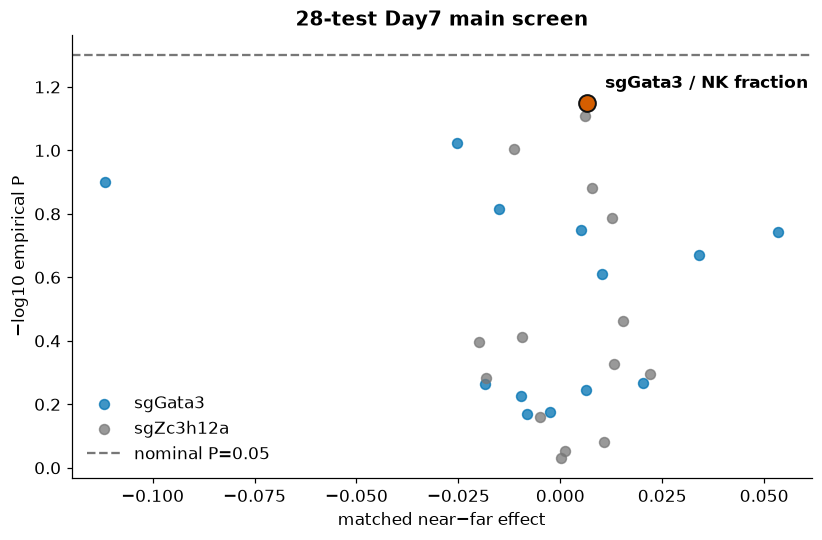

,guide,response,effect,ci_low,ci_high,permutation_p,global_fdr,replicate_direction_consistency
105,sgGata3,fraction_NK,0.0065,0.0001,0.0144,0.071,0.5068,1.0
147,sgZc3h12a,fraction_NK,0.0061,0.0001,0.0126,0.078,0.5068,1.0
99,sgGata3,exhaustion,-0.0253,-0.0496,0.0028,0.095,0.5068,1.0
148,sgZc3h12a,fraction_T,-0.0114,-0.0239,0.0028,0.099,0.5068,1.0
111,sgGata3,tgfb_ecm,-0.1116,-0.2505,0.0297,0.126,0.5068,0.5
142,sgZc3h12a,fraction_DC,0.0077,-0.0018,0.0178,0.131,0.5068,1.0
106,sgGata3,fraction_T,-0.0151,-0.0341,0.0065,0.153,0.5068,0.5
146,sgZc3h12a,fraction_Malignant,0.0126,-0.0043,0.0293,0.163,0.5068,1.0


In [5]:
main_screen["minus_log10_p"] = -np.log10(main_screen["permutation_p"].clip(lower=1e-6))
highlight = main_screen["guide"].eq("sgGata3") & main_screen["response"].eq("fraction_NK")
fig, ax = plt.subplots(figsize=(7.4, 4.8), constrained_layout=True)
for guide, rows in main_screen.groupby("guide", observed=True):
    color = COLORS["blue"] if guide == "sgGata3" else COLORS["gray"]
    ax.scatter(rows["effect"], rows["minus_log10_p"], s=42,
               color=color, alpha=0.75, label=guide)
selected = main_screen.loc[highlight].iloc[0]
ax.scatter([selected["effect"]], [selected["minus_log10_p"]], s=120,
           facecolor=COLORS["orange"], edgecolor="#111111", linewidth=1.3,
           zorder=5)
ax.annotate("sgGata3 / NK fraction", (selected["effect"], selected["minus_log10_p"]),
            xytext=(12, 10), textcoords="offset points", fontweight="bold")
ax.axhline(-np.log10(0.05), color=COLORS["gray"], linestyle="--",
           label="nominal P=0.05")
ax.set(xlabel="matched near−far effect", ylabel="−log10 empirical P")
ax.set_title("28-test Day7 main screen", fontweight="bold")
ax.legend(frameon=False)
plt.show()
display(main_screen.sort_values("permutation_p")[[
    "guide", "response", "effect", "ci_low", "ci_high",
    "permutation_p", "global_fdr",
    "replicate_direction_consistency",
]].head(8).round(4))

## 5. Matched NK-fraction response versus distance

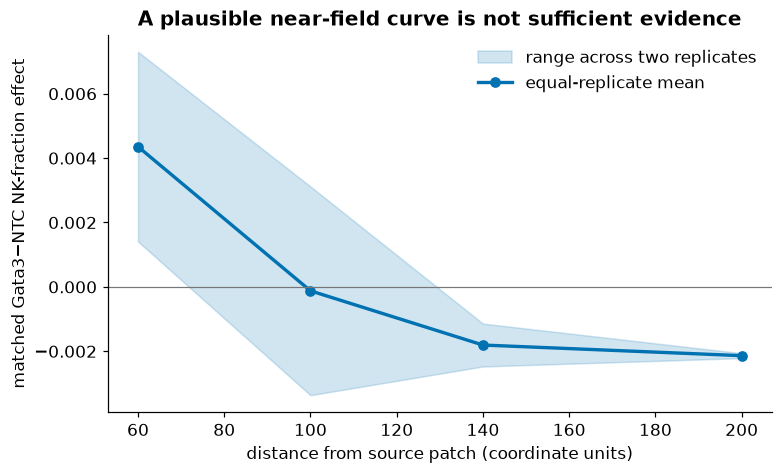

,guide,response,response_kind,target_cell_type,ring_midpoint,effect,sample_min,sample_max
0,sgGata3,fraction_NK,composition,NK,60.0,0.00435,0.00141,0.00730
1,sgGata3,fraction_NK,composition,NK,100.0,-0.00012,-0.00336,0.00312
2,sgGata3,fraction_NK,composition,NK,140.0,-0.00181,-0.00247,-0.00114
3,sgGata3,fraction_NK,composition,NK,200.0,-0.00214,-0.00221,-0.00206


In [6]:
fig, ax = plt.subplots(figsize=(7.0, 4.2), constrained_layout=True)
ax.fill_between(curve["ring_midpoint"], curve["sample_min"], curve["sample_max"],
                color=COLORS["blue"], alpha=0.18,
                label="range across two replicates")
ax.plot(curve["ring_midpoint"], curve["effect"], marker="o",
        linewidth=2.2, color=COLORS["blue"], label="equal-replicate mean")
ax.axhline(0, color=COLORS["gray"], linewidth=0.8)
ax.set(xlabel="distance from source patch (coordinate units)",
       ylabel="matched Gata3−NTC NK-fraction effect")
ax.set_title("A plausible near-field curve is not sufficient evidence",
             fontweight="bold")
ax.legend(frameon=False)
plt.show()
display(curve.round(5))

## 6. Nine-definition sensitivity

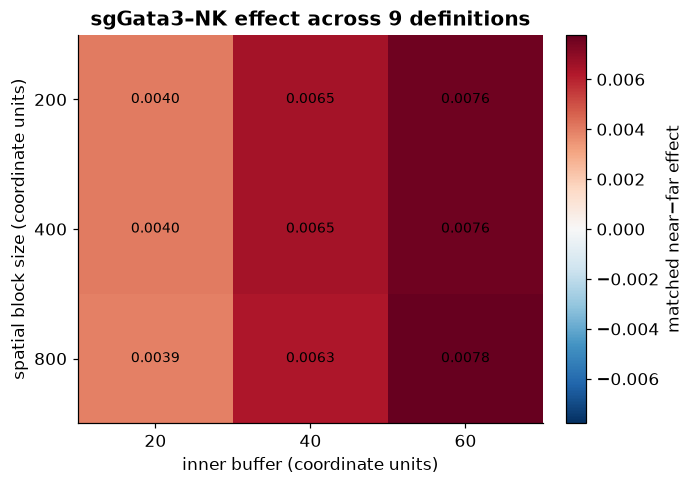

In [7]:
sensitivity = screen.loc[
    screen["guide"].eq("sgGata3")
    & screen["response"].eq("fraction_NK")
].copy()
matrix = sensitivity.pivot(index="block_size", columns="inner_buffer", values="effect")
fig, ax = plt.subplots(figsize=(6.2, 4.3), constrained_layout=True)
limit = np.abs(matrix.to_numpy()).max()
image = ax.imshow(matrix, cmap="RdBu_r", vmin=-limit, vmax=limit, aspect="auto")
for i, block in enumerate(matrix.index):
    for j, buffer in enumerate(matrix.columns):
        ax.text(j, i, f"{matrix.loc[block, buffer]:.4f}",
                ha="center", va="center", fontsize=9)
ax.set_xticks(range(len(matrix.columns)), [f"{value:g}" for value in matrix.columns])
ax.set_yticks(range(len(matrix.index)), [f"{value:g}" for value in matrix.index])
ax.set(xlabel="inner buffer (coordinate units)",
       ylabel="spatial block size (coordinate units)")
ax.set_title("sgGata3–NK effect across 9 definitions", fontweight="bold")
fig.colorbar(image, ax=ax, label="matched near−far effect")
plt.show()

## 7. Formal radius evidence gate

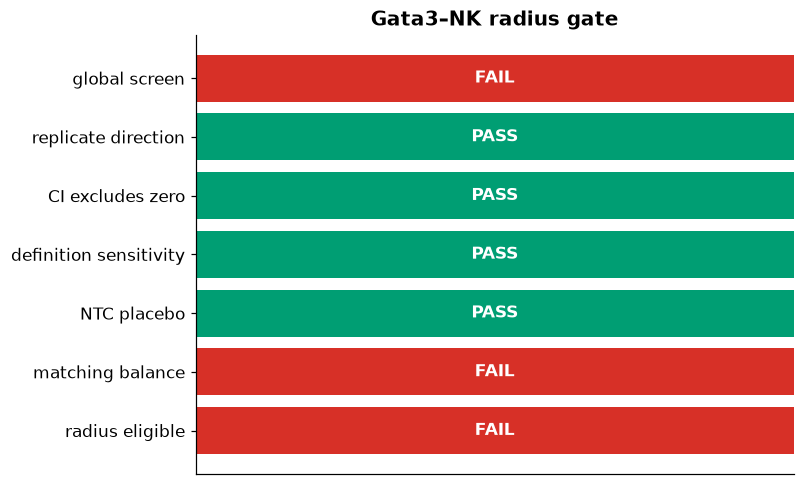

,quantity,value
0,effect,0.00649
1,95% interval,"[0.00014, 0.01444]"
2,empirical P,0.071
3,global FDR,0.507
4,replicate consistency,1.00
5,max |SMD|,0.426
6,balance threshold,≤ 0.25
7,radius eligible,False


In [8]:
row = gate.iloc[0]
checks = [
    ("global screen", bool(row["passes_screen"])),
    ("replicate direction", bool(row["passes_replicates"])),
    ("CI excludes zero", bool(row["passes_ci"])),
    ("definition sensitivity", bool(row["passes_sensitivity"])),
    ("NTC placebo", bool(row["passes_placebo"])),
    ("matching balance", bool(row["passes_balance"])),
    ("radius eligible", bool(row["radius_eligible"])),
]
labels = [label for label, _ in checks]
values = [value for _, value in checks]
colors = [COLORS["green"] if value else "#D73027" for value in values]
fig, ax = plt.subplots(figsize=(7.2, 4.3), constrained_layout=True)
ax.barh(labels, np.ones(len(labels)), color=colors)
for y, value in enumerate(values):
    ax.text(0.5, y, "PASS" if value else "FAIL", ha="center",
            va="center", color="white", fontweight="bold")
ax.set_xlim(0, 1)
ax.set_xticks([])
ax.invert_yaxis()
ax.set_title("Gata3–NK radius gate", fontweight="bold")
plt.show()

display(pd.DataFrame({
    "quantity": ["effect", "95% interval", "empirical P", "global FDR",
                 "replicate consistency", "max |SMD|", "balance threshold",
                 "radius eligible"],
    "value": [
        f"{row['effect']:.5f}",
        f"[{row['ci_low']:.5f}, {row['ci_high']:.5f}]",
        f"{row['permutation_p']:.3f}",
        f"{row['global_fdr']:.3f}",
        f"{row['replicate_direction_consistency']:.2f}",
        f"{row['max_abs_smd']:.3f}",
        "≤ 0.25",
        str(bool(row["radius_eligible"])),
    ],
}))

## Conclusion

Day7 sgGata3–NK fraction is directionally consistent across two
replicates and all nine spatial definitions, with a small positive
effect (+0.00649). Nevertheless, empirical P=0.071, global
FDR=0.507 and maximum matching |SMD|=0.426 fail the pre-specified
gates. The analysis therefore reports **no formal spatial radius**.
Coordinates remain in native units because a trustworthy
micrometre calibration was not established for this cohort.